In [ ]:
import os
import shutil
import random
from glob import glob

source_dir = "/home/teaching/ADL-project/data/Dataset_BUSI_with_GT"
target_dir = "/home/teaching/ADL-project/data/dataset"

os.makedirs(f"{target_dir}/train", exist_ok=True)
os.makedirs(f"{target_dir}/val", exist_ok=True)

split_ratio = 0.8

images = glob(os.path.join(source_dir, "*", "*.png"))
images = [img for img in images if "_mask" not in os.path.basename(img)]
random.shuffle(images)

split = int(split_ratio * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

for img in train_imgs:
    shutil.copy(img, f"{target_dir}/train/")

for img in val_imgs:
    shutil.copy(img, f"{target_dir}/val/")

print(f"Dataset split completed successfully!")
print(f"Train images: {len(train_imgs)}, Validation images: {len(val_imgs)}")


Dataset split completed successfully!
Train images: 624, Validation images: 156


In [45]:
dataset = {
    "train": glob("/home/teaching/ADL-project/notebooks/mitanshi/dataset/train/*.png"),
    "val": glob("/home/teaching/ADL-project/notebooks/mitanshi/dataset/val/*.png")
}


In [85]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_path = dataset["val"][2]  # first image
image = Image.open(img_path).convert("RGB")
width, height = image.size


In [50]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)
device ="cpu"

model.to(device)
model.train()


GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                    (attention): SwinAttention(
                      (self): SwinSelfAttention(
                        (query): Linear(in_features=96, out_features=96, bias=True)
                        (key): Linear(in_features=9

In [99]:
prompts = ["tumour. malignant."]
inputs = processor(images=image, text=prompts, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

pred_logits = outputs.logits[0]
pred_boxes = outputs.pred_boxes[0]

confidence_threshold = 0.35
probs = pred_logits.softmax(-1)[:, :-1]
scores, labels = probs.max(-1)
mask = scores > confidence_threshold

filtered_boxes_cxcywh = pred_boxes[mask]
filtered_scores = scores[mask]

boxes_xyxy = filtered_boxes_cxcywh.clone()
boxes_xyxy[:, 0] -= boxes_xyxy[:, 2]/2
boxes_xyxy[:, 1] -= boxes_xyxy[:, 3]/2
boxes_xyxy[:, 2] += boxes_xyxy[:, 0]
boxes_xyxy[:, 3] += boxes_xyxy[:, 1]

boxes_xyxy[:, [0,2]] *= width
boxes_xyxy[:, [1,3]] *= height


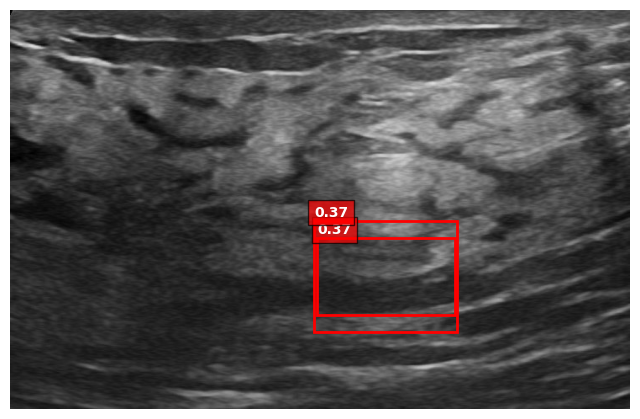

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(image)

for i, box in enumerate(boxes_xyxy):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1-5, f"{filtered_scores[i]:.2f}",
            bbox=dict(facecolor='red', alpha=0.7),
            fontsize=10, color='white', weight='bold')

ax.axis('off')
plt.show()


In [112]:
img_path = dataset["val"][52]  
image = Image.open(img_path).convert("RGB")


In [ ]:
#####

In [120]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from datasets import (
    Dataset,
    Features,
    Value,
    Image as HfImage,
    load_dataset,
    concatenate_datasets,
)
from PIL import Image as PilImage, ImageDraw, ImageFont
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision

In [121]:
def visualize_detections_matplotlib(image, detections):

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    label_to_color = {}

    for i, det in enumerate(detections):
        box = det["box"]
        label = det["label"]
        score = det["score"]

        if label not in label_to_color:
            label_to_color[label] = colors[len(label_to_color) % 10]
        color = label_to_color[label]

        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min

        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=3, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        label_text = f"{label}: {score:.2f}"
        ax.text(
            x_min, y_min - 5,
            label_text,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.7),
            fontsize=10, color='white', weight='bold'
        )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [122]:
def box_cxcywh_to_xyxy(boxes):
    x_c, y_c, w, h = boxes.unbind(-1)
    b = [
        (x_c - 0.5 * w),
        (y_c - 0.5 * h),
        (x_c + 0.5 * w),
        (y_c + 0.5 * h)
    ]
    return torch.stack(b, dim=-1)
def custom_nms(boxes, scores, iou_threshold=0.7):

    if len(boxes) == 0:
        return torch.tensor([])

    keep = torchvision.ops.nms(boxes, scores, iou_threshold)
    return keep

In [123]:
base_dir = "/home/teaching/ADL-project/notebooks/mitanshi/Dataset_BUSI_with_GT"

records = []
for label in ["benign", "malignant"]:
    folder = os.path.join(base_dir, label)
    for file in os.listdir(folder):
        if not file.endswith(".png") or "mask" in file:
            continue

        img_path = os.path.join(folder, file)

        base_name = file.replace(".png", "")
        mask_files = [
            f for f in os.listdir(folder) if f.startswith(base_name + "_mask")
        ]

        if mask_files:
            masks = []
            for m in mask_files:
                mask_img = np.array(PilImage.open(
                    os.path.join(folder, m)).convert("L"))
                masks.append(mask_img > 0)

            merged_mask = np.any(masks, axis=0).astype(np.uint8) * 255
            conditioning_image = PilImage.fromarray(merged_mask)
        else:
            conditioning_image_path = None

        records.append(
            {
                "image": img_path,
                "conditioning_image": conditioning_image,
                "caption": label,
            }
        )

features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

kaggle_dataset = Dataset.from_list(records, features=features)

hf = load_dataset("Amss007/ultrasound_dataset_v3_1", cache_dir="../data")

features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

kaggle_dataset = kaggle_dataset.cast(features)

hf_dataset = hf["train"]
hf_dataset = hf_dataset.cast(features)

merged_dataset = concatenate_datasets([kaggle_dataset, hf_dataset])

print(merged_dataset)

Casting the dataset:   0%|          | 0/647 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'conditioning_image', 'caption'],
    num_rows: 4632
})


In [138]:
sample = merged_dataset[1]
image = sample["image"]

prompts = ["circular patch. " +
           sample['caption']]

In [125]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "IDEA-Research/grounding-dino-tiny"
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
processor = AutoProcessor.from_pretrained(model_id, use_fast=False)

inputs = processor(images=image, text=prompts, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}  # critical step

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.keys())


odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'init_reference_points', 'intermediate_hidden_states', 'intermediate_reference_points', 'encoder_last_hidden_state_vision', 'encoder_last_hidden_state_text', 'enc_outputs_class', 'enc_outputs_coord_logits', 'encoder_logits', 'encoder_pred_boxes', 'input_ids'])


Detected class 2 with score 0.50 at [302.0, 95.0, 410.0, 162.0]
Detected class 1 with score 0.47 at [0.0, 0.0, 544.0, 469.0]
Detected class 1 with score 0.46 at [0.0, 0.0, 5.0, 15.0]
Detected class 1 with score 0.45 at [0.0, 0.0, 5.0, 39.0]
Detected class 1 with score 0.46 at [0.0, 0.0, 4.0, 30.0]
Detected class 1 with score 0.46 at [0.0, 0.0, 544.0, 367.0]
Detected class 2 with score 0.44 at [0.0, 0.0, 29.0, 15.0]
Detected class 1 with score 0.44 at [0.0, 0.0, 12.0, 16.0]
Detected class 1 with score 0.44 at [0.0, 0.0, 4.0, 70.0]
Detected class 2 with score 0.42 at [0.0, 0.0, 44.0, 15.0]
Detected class 1 with score 0.45 at [0.0, 254.0, 544.0, 469.0]
Detected class 1 with score 0.45 at [0.0, 0.0, 2.0, 37.0]
Detected class 1 with score 0.45 at [240.0, 11.0, 319.0, 29.0]
Detected class 2 with score 0.43 at [0.0, 0.0, 63.0, 15.0]
Detected class 1 with score 0.41 at [512.0, 466.0, 544.0, 469.0]
Detected class 1 with score 0.43 at [0.0, 0.0, 27.0, 30.0]
Detected class 1 with score 0.43 at [0

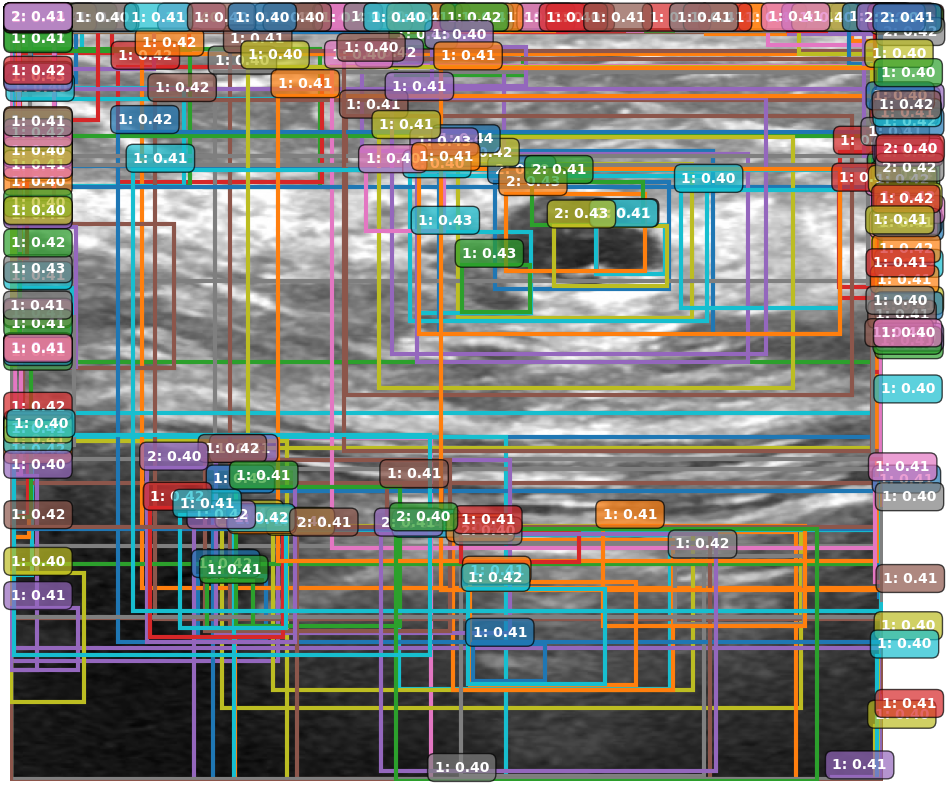

In [128]:
pred_logits = outputs.logits[0]
pred_boxes = outputs.pred_boxes[0]

threshold = 0.4
probs = pred_logits.softmax(-1)[:, :-1]
scores, labels = probs.max(-1)
mask = scores > threshold

filtered_boxes_normalized  = pred_boxes[mask]
filtered_scores = scores[mask]
filtered_labels = labels[mask]

width, height = image.size
boxes_corner = filtered_boxes_normalized.clone()
boxes_corner[:, 0] = (filtered_boxes_normalized[:, 0] - filtered_boxes_normalized[:, 2] / 2) * width
boxes_corner[:, 1] = (filtered_boxes_normalized[:, 1] - filtered_boxes_normalized[:, 3] / 2) * height
boxes_corner[:, 2] = (filtered_boxes_normalized[:, 0] + filtered_boxes_normalized[:, 2] / 2) * width
boxes_corner[:, 3] = (filtered_boxes_normalized[:, 1] + filtered_boxes_normalized[:, 3] / 2) * height

filtered_detections = []
for box, score, label in zip(boxes_corner, filtered_scores, filtered_labels):
    x1, y1, x2, y2 = map(lambda x:round(x), box.tolist())
    filtered_detections.append({
            "label": label,
            "score": score.item(),
            "box": box.tolist()
        })
    print(
        f"Detected class {label.item()} with score {score.item():.2f} at [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

visualize_detections_matplotlib(image, filtered_detections)

Detected: circular patch with confidence 0.48
Detected: big benign with confidence 0.51
Detected: circular patch with confidence 0.45
Detected: big benign with confidence 0.41

Total detections above threshold: 4


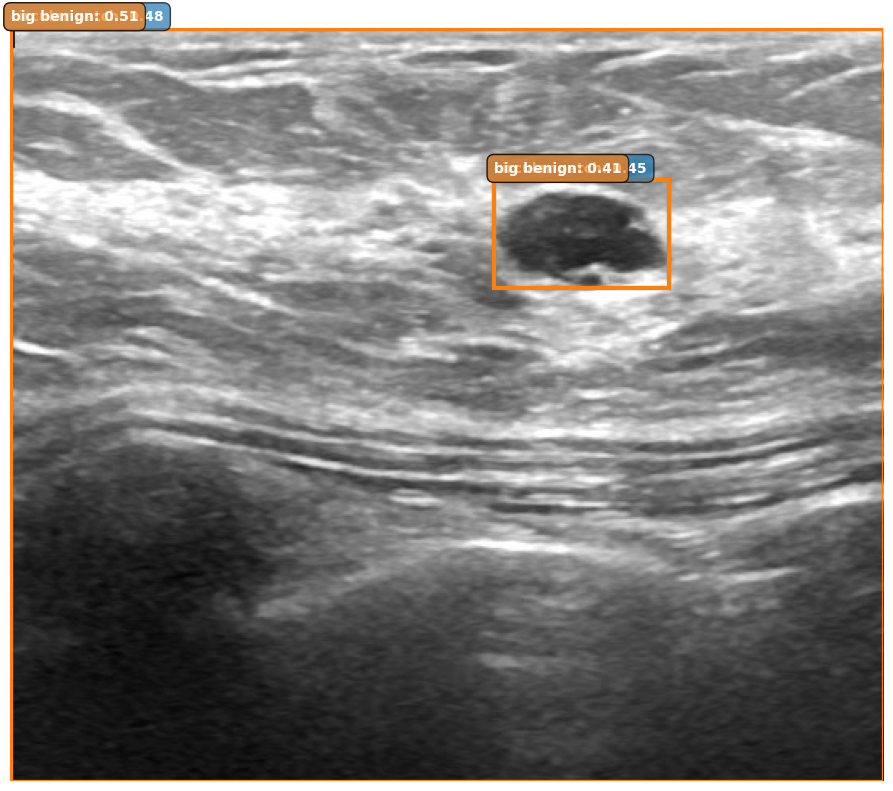

In [139]:
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    target_sizes=[image.size[::-1]]
)

threshold = 0.3

post_labels = results[0]["text_labels"]
post_scores = results[0]["scores"]
post_boxes = results[0]["boxes"]

filtered_detections = []
for label, score, box in zip(post_labels, post_scores, post_boxes):
    if score >= threshold:
        filtered_detections.append({
            "label": label,
            "score": score.item(),
            "box": box.tolist()
        })
        print(f"Detected: {label} with confidence {score:.2f}")

print(f"\nTotal detections above threshold: {len(filtered_detections)}")

visualize_detections_matplotlib(image, filtered_detections)

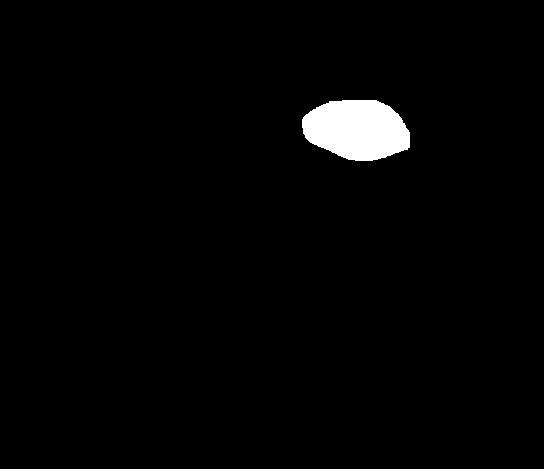

In [140]:
sample["conditioning_image"]

In [141]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()


GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                    (attention): SwinAttention(
                      (self): SwinSelfAttention(
                        (query): Linear(in_features=96, out_features=96, bias=True)
                        (key): Linear(in_features=9

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=1e-5)

num_epochs = 3
confidence_threshold = 0.4
iou_threshold = 0.5

for epoch in range(num_epochs):
    total_boxes = 0
    for sample in merged_dataset:
        image = sample["image"]             
        prompt = sample["caption"]         

        inputs = processor(
            images=image,
            text=[prompt],
            return_tensors="pt"
        ).to(device)

        optimizer.zero_grad()
        outputs = model(**inputs)

        pred_logits = outputs.logits[0]
        pred_boxes = outputs.pred_boxes[0]

        probs = pred_logits.softmax(-1)[:, :-1]
        scores, labels = probs.max(-1)
        mask = scores > confidence_threshold

        if mask.sum() == 0:
            continue

        pseudo_boxes = pred_boxes[mask]

        loss = 1 - scores[mask].mean()
        loss.backward()
        optimizer.step()

        total_boxes += len(pseudo_boxes)

    print(f"Epoch {epoch+1}: Processed {len(merged_dataset)} images, total pseudo-boxes: {total_boxes}")


In [ ]:
model.save_pretrained("./grounding_dino_finetuned")
processor.save_pretrained("./grounding_dino_finetuned")

In [1]:
###########

In [3]:
from datasets import load_dataset
ds=load_dataset("/home/teaching/ADL-project/notebooks/data/Amss007___ultrasound_dataset_v3_1")

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'conditioning_image', 'caption'],
        num_rows: 3985
    })
})


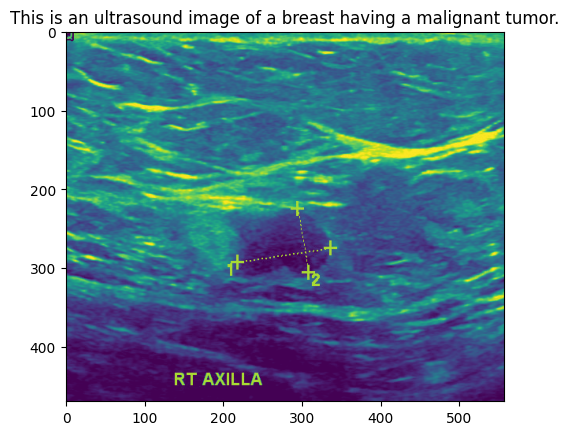

In [16]:
import matplotlib.pyplot as plt
plt.imshow(ds['train'][2330]['image'])
plt.title(ds['train'][2330]['caption'])
plt.show()

In [17]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = AutoModel.from_pretrained("facebook/dinov2-base")


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [29]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),          # Converts PIL Image to Tensor
    transforms.Normalize(mean=[0.5], std=[0.5]) 
])

def preprocess(ex):
    ex["pixel_values"]=transform(ex["image"])
    ex["pixel_values"]=processor(images=ex["image"],return_tensors="pt")["pixel_values"][0]
    return ex

train_ds=ds['train'].map(preprocess)

Map:   0%|          | 0/3985 [00:00<?, ? examples/s]

In [19]:
#image embedding +text embedding for training prompt-conditioned dino

In [20]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [21]:
def add_text_embeddings(ex):
    ex["input_ids"]=tokenizer(ex["caption"],padding="max_length",truncation=True,return_tensors="pt")["input_ids"][0]
    return ex

train_ds=train_ds.map(add_text_embeddings)

Map:   0%|          | 0/3985 [00:00<?, ? examples/s]

In [22]:
import torch
import torch.nn as nn

class PromptDINO(nn.Module):
    def __init__(self,image_encoder,text_encoder,hidden_dim=768):
        super().__init__()
        self.image_encoder=image_encoder
        self.text_encoder=text_encoder
        self.proj_image=nn.Linear(hidden_dim,hidden_dim)
        self.proj_text=nn.Linear(hidden_dim,hidden_dim)
        self.loss_fn=nn.CosineEmbeddingLoss()

    def forward(self,pixel_values,input_ids):
        img_emb=self.image_encoder(pixel_values).last_hidden_state.mean(dim=1)
        text_emb=self.text_encoder(input_ids).last_hidden_state.mean(dim=1)
        img_emb=self.proj_image(img_emb)
        text_emb=self.proj_text(text_emb)
        return img_emb,text_emb
    

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()  # converts PIL image or list to tensor
])

def preprocess(example):
    example["pixel_values"] = transform(example["image"])
    return example

train_ds = ds["train"].map(preprocess)

def collate_fn(batch):
    pixel_values=torch.stack([b["pixel_values"] for b in batch])
    input_ids=torch.stack([b["input_ids"] for b in batch])
    return {"pixel_values": pixel_values, "input_ids": input_ids}

train_loader=DataLoader(train_ds,batch_size=8,shuffle=True,collate_fn=collate_fn)

In [26]:
import torch.optim as optim
from transformers import AutoModel

image_encoder = AutoModel.from_pretrained("facebook/dinov2-base")
text_encoder = AutoModel.from_pretrained("bert-base-uncased")

model=PromptDINO(image_encoder=image_encoder,text_encoder=text_encoder)
model = model.to(device)

loss_fn=nn.CosineEmbeddingLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-4)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [42]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

# 1️⃣ Define transform: handles list, PIL, or numpy array
transform = transforms.Compose([
    transforms.Lambda(lambda x: Image.fromarray(x) if isinstance(x, list) else x),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),  # -> Tensor shape (C,H,W)
])

# 2️⃣ Preprocess dataset
def preprocess(example):
    example["pixel_values"] = transform(example["image"])
    # Convert text caption to tensor if needed (dummy example for now)
    # You should tokenize with your tokenizer if using prompt-based DINO
    example["input_ids"] = torch.tensor([0])  # placeholder, replace with actual tokenization
    return example

train_ds = ds["train"].map(preprocess)

# 3️⃣ Collate function: now safe
def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    input_ids = torch.stack([b["input_ids"] for b in batch])
    return {"pixel_values": pixel_values, "input_ids": input_ids}

# 4️⃣ DataLoader
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn)

# 5️⃣ Sanity check
batch = next(iter(train_loader))
print("pixel_values shape:", batch["pixel_values"].shape)
print("input_ids shape:", batch["input_ids"].shape)
print("pixel_values type:", type(batch["pixel_values"][0]))


Map:   0%|          | 0/3985 [00:00<?, ? examples/s]

TypeError: expected Tensor as element 0 in argument 0, but got list